In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Experiment 1

In [4]:
# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define paths
train_path = '/Users/prernaalkute/Documents/Project/train'
test_path = '/Users/prernaalkute/Documents/Project/test'

# Define transformations (Data Augmentation + Normalization)
transform = transforms.Compose([
    transforms.Resize((128, 128)),  # Resize images to 128x128
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.2),  # Color augmentation
    transforms.RandomResizedCrop(128, scale=(0.8, 1.0)),  # Randomly crop and resize
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # Normalization
])

# Load datasets
train_dataset = datasets.ImageFolder(root=train_path, transform=transform)
test_dataset = datasets.ImageFolder(root=test_path, transform=transform)

# Define class names
class_names = train_dataset.classes
num_classes = len(class_names)

# Define DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Dynamically determine input size
sample_image, _ = next(iter(train_loader))
_, C, H, W = sample_image.shape  # Get image channels, height, width
input_size = H * W * C  # Flattened image size

# Define Neural Network Model
class NNModel(nn.Module):
    def __init__(self, input_size, hidden_units, output_size):
        super(NNModel, self).__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),  # Flatten input image
            nn.Linear(input_size, hidden_units),  # First hidden layer
            nn.ReLU(),
            nn.BatchNorm1d(hidden_units),  # Batch Normalization
            nn.Dropout(0.5),  # Dropout for regularization
            nn.Linear(hidden_units, hidden_units // 2),  # Second hidden layer
            nn.ReLU(),
            nn.BatchNorm1d(hidden_units // 2),
            nn.Dropout(0.5),
            nn.Linear(hidden_units // 2, output_size)  # Output layer
        )

    def forward(self, x):
        return self.layer_stack(x)

# Initialize model, loss function, and optimizer
model = NNModel(input_size=input_size, hidden_units=512, output_size=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)


# Lists to track loss and accuracy
train_losses = []
train_accuracies = []

# Train the model
num_epochs = 40
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        images = images.view(images.size(0), -1)  # Flatten images

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_accuracy = correct / total
    train_losses.append(running_loss / len(train_loader))
    train_accuracies.append(train_accuracy)

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {train_losses[-1]:.4f}, Accuracy: {train_accuracies[-1]:.4f}")



Epoch [1/40], Loss: 2.7127, Accuracy: 0.1325
Epoch [2/40], Loss: 2.5943, Accuracy: 0.1618
Epoch [3/40], Loss: 2.5266, Accuracy: 0.1783
Epoch [4/40], Loss: 2.4967, Accuracy: 0.1873
Epoch [5/40], Loss: 2.4728, Accuracy: 0.1958
Epoch [6/40], Loss: 2.4472, Accuracy: 0.2128
Epoch [7/40], Loss: 2.4385, Accuracy: 0.2110
Epoch [8/40], Loss: 2.4286, Accuracy: 0.2090
Epoch [9/40], Loss: 2.4245, Accuracy: 0.2100
Epoch [10/40], Loss: 2.4078, Accuracy: 0.2258
Epoch [11/40], Loss: 2.4237, Accuracy: 0.2242
Epoch [12/40], Loss: 2.4123, Accuracy: 0.2177
Epoch [13/40], Loss: 2.4139, Accuracy: 0.2203
Epoch [14/40], Loss: 2.4086, Accuracy: 0.2228
Epoch [15/40], Loss: 2.4039, Accuracy: 0.2230
Epoch [16/40], Loss: 2.4078, Accuracy: 0.2215
Epoch [17/40], Loss: 2.4095, Accuracy: 0.2202
Epoch [18/40], Loss: 2.3869, Accuracy: 0.2247
Epoch [19/40], Loss: 2.4049, Accuracy: 0.2192
Epoch [20/40], Loss: 2.4068, Accuracy: 0.2293
Epoch [21/40], Loss: 2.4009, Accuracy: 0.2307
Epoch [22/40], Loss: 2.3912, Accuracy: 0.22

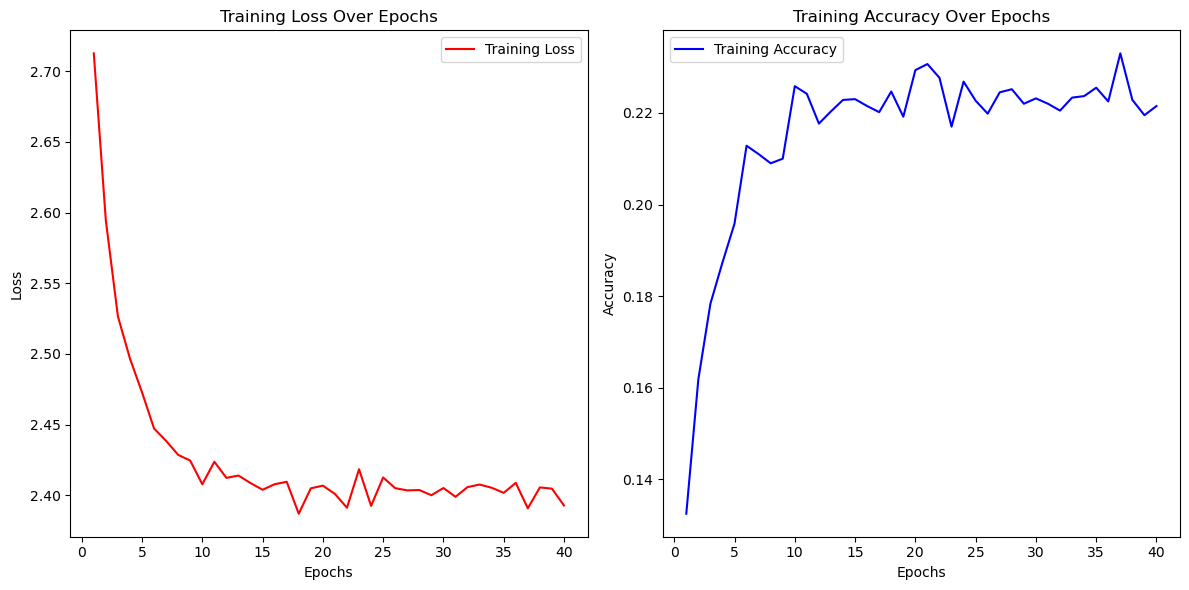

In [7]:
# Plot training loss and accuracy
epochs = range(1, num_epochs + 1)

# Loss plot
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Training Loss', color='red')
plt.title("Training Loss Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, label='Training Accuracy', color='blue')
plt.title("Training Accuracy Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

Test Accuracy: 0.2480
Neural Network Classifier Performance:
              precision    recall  f1-score   support

   n01644900       0.16      0.09      0.12       100
   n01944390       0.16      0.08      0.11       100
   n01945685       0.29      0.06      0.10       100
   n02129165       0.22      0.18      0.20       100
   n02206856       0.36      0.25      0.29       100
   n02233338       0.20      0.34      0.25       100
   n02437312       0.25      0.25      0.25       100
   n02666196       0.12      0.01      0.02       100
   n02669723       0.36      0.31      0.33       100
   n02699494       0.18      0.28      0.22       100
   n02791270       0.19      0.34      0.25       100
   n02948072       0.41      0.35      0.38       100
   n03026506       0.40      0.36      0.38       100
   n03042490       0.20      0.31      0.25       100
   n03100240       0.26      0.51      0.34       100

    accuracy                           0.25      1500
   macro avg       

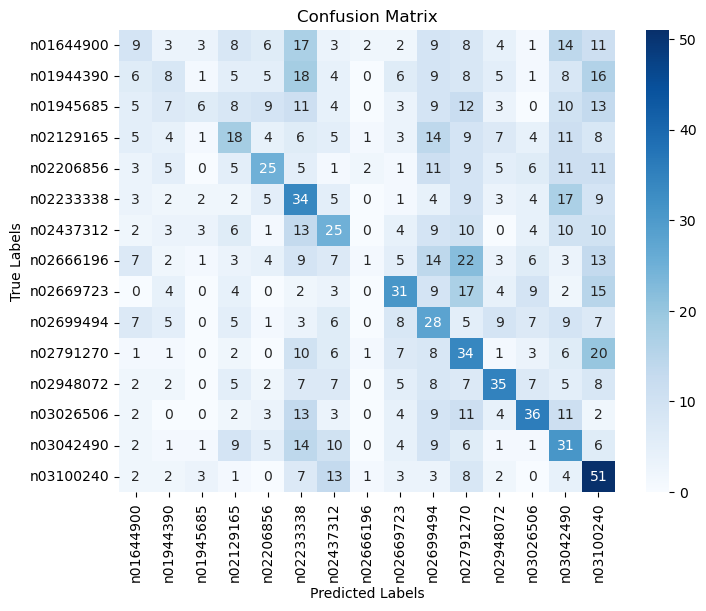

In [9]:
# Evaluate the model
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        images = images.view(images.size(0), -1)  # Flatten images
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

test_accuracy = correct / total
print(f"Test Accuracy: {test_accuracy:.4f}")

# Print classification report
print("Neural Network Classifier Performance:")
print(classification_report(all_labels, all_preds, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()


# Experiment 2

In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define paths
train_path = '/Users/prernaalkute/Documents/Project/train'
test_path = '/Users/prernaalkute/Documents/Project/test'

# Define improved transformations
transform = transforms.Compose([
    transforms.Resize((128, 128)),  # Resize images to 128x128
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomResizedCrop(128, scale=(0.9, 1.0)),  # Less aggressive cropping
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # Normalization
])

# Load datasets
train_dataset = datasets.ImageFolder(root=train_path, transform=transform)
test_dataset = datasets.ImageFolder(root=test_path, transform=transform)

# Define class names
class_names = train_dataset.classes
num_classes = len(class_names)

# Define DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Dynamically determine input size
sample_image, _ = next(iter(train_loader))
_, C, H, W = sample_image.shape  # Get image channels, height, width
input_size = H * W * C  # Flattened image size

# Define Neural Network Model with Improvements
class ImprovedNNModel(nn.Module):
    def __init__(self, input_size, hidden_units, output_size):
        super(ImprovedNNModel, self).__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_size, hidden_units),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_units),
            nn.Dropout(0.3),  # Reduced dropout
            nn.Linear(hidden_units, hidden_units // 2),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_units // 2),
            nn.Dropout(0.3),
            nn.Linear(hidden_units // 2, output_size)
        )

    def forward(self, x):
        return self.layer_stack(x)

# Initialize model, loss function, and optimizer
model = ImprovedNNModel(input_size=input_size, hidden_units=512, output_size=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-4)  # Lower learning rate
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# Lists to track loss and accuracy
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

# Early stopping
early_stopping_patience = 7
best_val_loss = float('inf')
epochs_no_improve = 0

# Save PyTorch model
torch.save(model.state_dict(), "phase3_model.pth")

# Load PyTorch model
model.load_state_dict(torch.load("phase3_model.pth", weights_only=True))
model.eval()

# Train the model
num_epochs = 50
for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        images = images.view(images.size(0), -1)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_accuracy = correct / total
    train_losses.append(running_loss / len(train_loader))
    train_accuracies.append(train_accuracy)

    # Validation Phase
    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            images = images.view(images.size(0), -1)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    val_accuracy = correct / total
    val_losses.append(val_loss / len(test_loader))
    val_accuracies.append(val_accuracy)

    scheduler.step(val_losses[-1])

    print(f"Epoch [{epoch+1}/{num_epochs}] -> Train Loss: {train_losses[-1]:.4f}, Train Acc: {train_accuracies[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}, Val Acc: {val_accuracies[-1]:.4f}")

    # Early stopping
    if val_losses[-1] < best_val_loss:
        best_val_loss = val_losses[-1]
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= early_stopping_patience:
            print("Early stopping triggered!")
            break


Epoch [1/50] -> Train Loss: 2.5487, Train Acc: 0.1798, Val Loss: 2.3692, Val Acc: 0.2427
Epoch [2/50] -> Train Loss: 2.3651, Train Acc: 0.2375, Val Loss: 2.2698, Val Acc: 0.2747
Epoch [3/50] -> Train Loss: 2.2995, Train Acc: 0.2558, Val Loss: 2.2556, Val Acc: 0.2893
Epoch [4/50] -> Train Loss: 2.2345, Train Acc: 0.2830, Val Loss: 2.2201, Val Acc: 0.3093
Epoch [5/50] -> Train Loss: 2.1990, Train Acc: 0.2900, Val Loss: 2.1902, Val Acc: 0.3020
Epoch [6/50] -> Train Loss: 2.1676, Train Acc: 0.3047, Val Loss: 2.1589, Val Acc: 0.3140
Epoch [7/50] -> Train Loss: 2.1500, Train Acc: 0.3097, Val Loss: 2.1576, Val Acc: 0.3153
Epoch [8/50] -> Train Loss: 2.1216, Train Acc: 0.3187, Val Loss: 2.1630, Val Acc: 0.3133
Epoch [9/50] -> Train Loss: 2.0935, Train Acc: 0.3248, Val Loss: 2.1310, Val Acc: 0.3213
Epoch [10/50] -> Train Loss: 2.1030, Train Acc: 0.3252, Val Loss: 2.1379, Val Acc: 0.3167
Epoch [11/50] -> Train Loss: 2.0635, Train Acc: 0.3347, Val Loss: 2.1311, Val Acc: 0.3267
Epoch [12/50] -> Tr

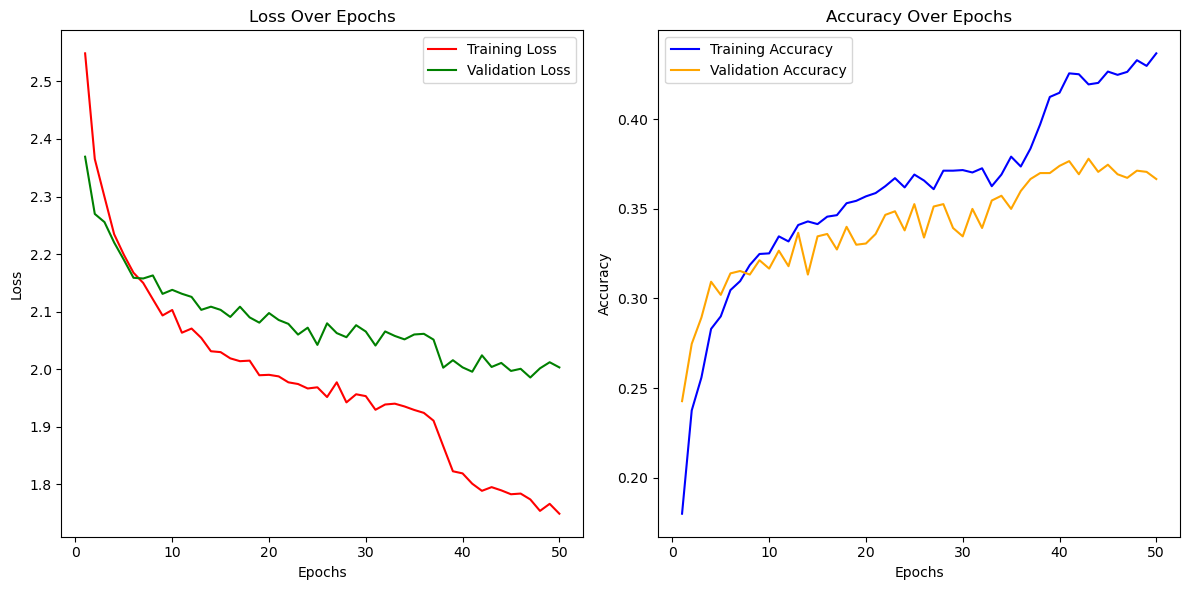

In [25]:
# Plot training and validation loss & accuracy
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Training Loss', color='red')
plt.plot(epochs, val_losses, label='Validation Loss', color='green')
plt.title("Loss Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, label='Training Accuracy', color='blue')
plt.plot(epochs, val_accuracies, label='Validation Accuracy', color='orange')
plt.title("Accuracy Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()



Neural Network Classifier Performance:
              precision    recall  f1-score   support

   n01644900       0.26      0.29      0.27       100
   n01944390       0.28      0.16      0.20       100
   n01945685       0.20      0.09      0.12       100
   n02129165       0.35      0.32      0.34       100
   n02206856       0.47      0.52      0.50       100
   n02233338       0.31      0.33      0.32       100
   n02437312       0.43      0.43      0.43       100
   n02666196       0.25      0.13      0.17       100
   n02669723       0.46      0.39      0.42       100
   n02699494       0.36      0.44      0.40       100
   n02791270       0.29      0.40      0.33       100
   n02948072       0.40      0.47      0.43       100
   n03026506       0.47      0.52      0.50       100
   n03042490       0.35      0.44      0.39       100
   n03100240       0.52      0.66      0.58       100

    accuracy                           0.37      1500
   macro avg       0.36      0.37      0

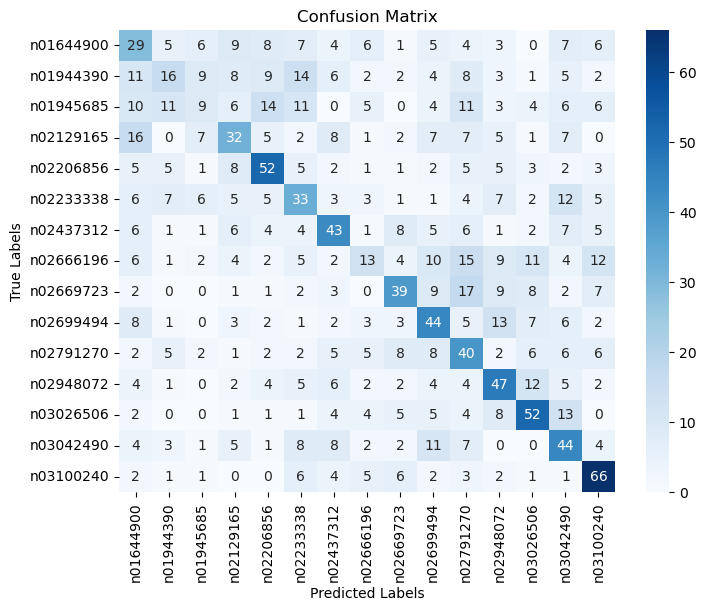

In [27]:
# Evaluate the model and print classification report
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        images = images.view(images.size(0), -1)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Print classification report
print("\nNeural Network Classifier Performance:")
print(classification_report(all_labels, all_preds, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()
